# Use MIOFlow to infer trajectories on PHATE space

Prerequisites:
- You have preprocessed your data and saved a mioflow DataFrame [notebook: 3-time-pseudotime]: 
    - rows are cells
    - columns are embeddings dimensions
    - "samples" are the discrete time labels


In this notebook, we will:
- Run MIOFlow on our PHATE space to infer trajectories

## 1. Importing MIOFlow and defining data paths

In [29]:
from MIOFlow.utils import generate_steps, set_seeds, config_criterion
from MIOFlow.models import make_model, Autoencoder
from MIOFlow.plots import plot_comparision, plot_losses
from MIOFlow.train import train_ae, training_regimen

from MIOFlow.geo import setup_distance
from MIOFlow.exp import setup_exp
from MIOFlow.eval import generate_plot_data

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


adata = sc.read_h5ad('/gpfs/gibbs/pi/krishnaswamy_smita/xingzhi/cflows/data/rna_figure_ready.h5ad')

## 1. Retrieve the data and embedding normalization
First we retrieve the data.

Then, we will normalize the embeddings as a standard procedure to enable our network to learn better.

**Attention:** It is important to save the _std_ and _mean_ values. 

It is important to save the _std_ and _mean_ values because when decoding back using the `DimChanger`, we need to ensure that the outputs follow the distributions of the initial embeddings.

In [8]:
adata.obs

,n_counts,batch,day,new,sample_id,growth,log_growth,sample_labels,louvain,S_score,G2M_score,phase,emt_scores
AAACCTGAGTTCGCGC-1-4,12874.0,4,0.0,0,0,1.247017,0.318481,0,5,0.104677,0.249283,G2M,0.244868
AAACCTGCAGGACCCT-1-4,12520.0,4,0.0,0,0,0.459218,-1.122749,0,6,0.109079,-0.014701,S,6.117601
AAACCTGCATGTTGAC-1-4,10850.0,4,0.0,0,0,0.545286,-0.874916,0,5,-0.131493,-0.394984,G1,0.828480
AAACCTGGTCGAACAG-1-4,8351.0,4,0.0,0,0,1.386842,0.471803,0,5,-0.009297,-0.205679,G1,-0.143657
AAACCTGTCCGTTGCT-1-4,7429.0,4,0.0,0,0,0.067749,-3.883659,0,5,-0.117484,-0.235224,G1,-0.236617
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCCGCTGTT-1-8,6701.0,8,30.0,0,30,NaN,NaN,4,11,0.192874,0.153021,S,-0.381007
TTTGGTTTCTGCGGCA-1-8,10274.0,8,30.0,0,30,NaN,NaN,4,2,-0.122540,-0.210936,G1,-0.418274
TTTGTCACAGTCTTCC-1-8,21244.0,8,30.0,0,30,NaN,NaN,4,2,0.152778,-0.151314,S,0.455980
TTTGTCAGTACTTGAC-1-8,23182.0,8,30.0,0,30,NaN,NaN,4,2,-0.113618,-0.293476,G1,-0.614758


In [15]:
# Create a numerical bin for each unique value
adata.obs['discrete_time'], _ = pd.factorize(adata.obs['day'])

#Now lets create the data structure that mioflows works on top
mioflow_df = pd.DataFrame(adata.obsm['X_phate'], columns=[f'd{i}' for i in range(1, adata.obsm['X_phate'].shape[1]+1)])

# Add the time labels to the dataframe as a column called 'samples' (this is expected by MIOFlow)
mioflow_df['samples'] = adata.obs['discrete_time'].values
mioflow_df

,d1,d2,samples
0,0.036356,-0.005683,0
1,0.039413,0.000519,0
2,0.034858,-0.003345,0
3,0.030872,-0.004870,0
4,0.034578,-0.002362,0
...,...,...,...
16980,0.004354,0.017672,4
16981,-0.007092,0.008804,4
16982,-0.012404,0.003051,4
16983,-0.012093,0.009553,4


In [16]:
# Get embedding columns dynamically
embed_cols = [col for col in mioflow_df.columns if col.startswith('d') and col[1:].isdigit()] # Retrieve the columns that start with a d
embedding = mioflow_df[embed_cols].values
embedding

array([[ 0.03635562, -0.00568341],
       [ 0.0394135 ,  0.0005191 ],
       [ 0.03485788, -0.00334511],
       ...,
       [-0.01240443,  0.00305071],
       [-0.01209324,  0.00955291],
       [-0.0103405 ,  0.01165974]])

### Normalizing the data

In [17]:
# Normalize across all dimensions properly
mean_vals = np.mean(embedding, axis=0)
std_vals = np.std(embedding, axis=0)
std_vals = np.where(std_vals == 0, 1, std_vals)  # Prevent division by zero
normalized = (embedding - mean_vals) / std_vals
# Normalized that is going to be used to train the network
normalized

array([[ 2.16492859, -0.49814357],
       [ 2.3320683 ,  0.17329064],
       [ 2.08306395, -0.24501768],
       ...,
       [-0.50023261,  0.44734295],
       [-0.48322344,  1.15121894],
       [-0.38742085,  1.37928859]])

In [18]:
# We create the dataframe with the normalized data and the samples
df = pd.DataFrame(normalized, columns=[f'd{i+1}' for i in range(normalized.shape[1])])
df['samples'] = mioflow_df['samples']
df.head(1)

,d1,d2,samples
0,2.164929,-0.498144,0


In [19]:
# Retrieve the number of samples that are in the less representative class.
min_count = df['samples'].value_counts().min()

### [Optional] We can resample our dataset to take an equal number of samples across the time_labels.

Only uncomment the following lines if you want to resample the dataset!

In [20]:
# # Retrieve the number of samples that are in the less representative class.
# min_count = df['samples'].value_counts().min()
# # Subsample the dataset to keep the same number of samples across all possible samples
# df = df.groupby('samples').apply(lambda x: x.sample(min_count)).reset_index(drop=True)

### Let's visualize what will be our input data using PHATE

If your data looks right, and we can see a path for the trajectories to follow, we can move on to training the MIOFlow algorithm

<Axes: xlabel='d1', ylabel='d2'>

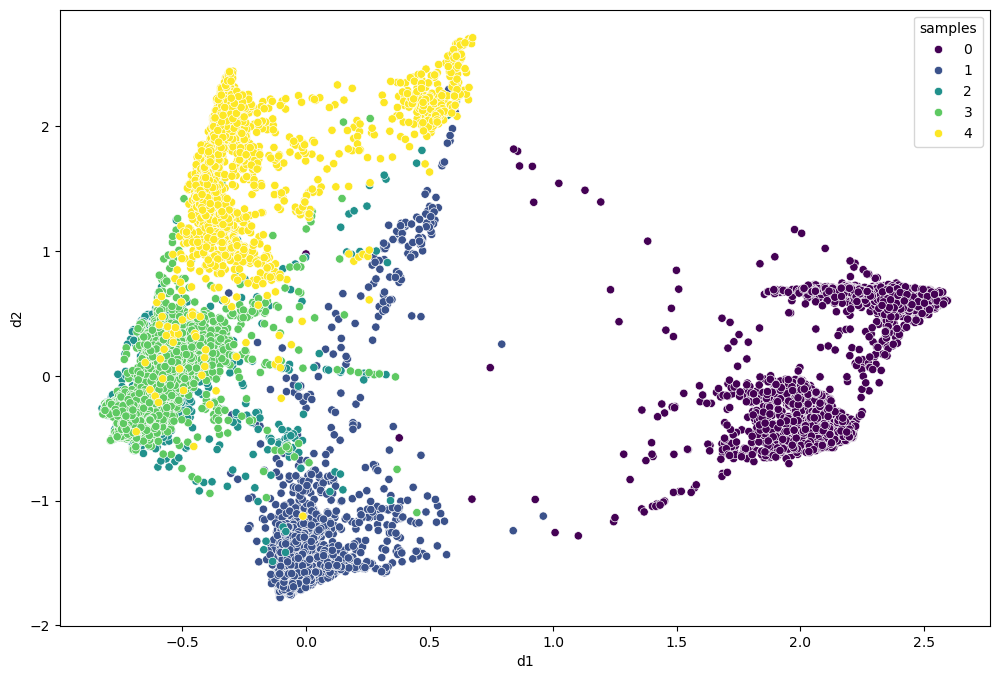

In [21]:
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='d1', y='d2', hue='samples', palette='viridis')

# Training the MIOFlow Model

A lot of this initial cells will be just setting up configurations to run the MIOFlow algorithm.

In [22]:
# Import torch library and verify if GPUs are available to be used.
import torch
set_seeds(0)
use_cuda = torch.cuda.is_available()

In [31]:
# Here we create the model using the MIOFlow library

model = make_model(
    feature_dims = (len(df.columns) - 1),# The dimensions in the input space, it is columns - 1 because we assume one column is equal to "samples"., 
    layers = [16,32,16], # Can change but we never really do, mostly depends on the dataset.
    activation='CELU',
    scales=None, #sde_scales
    use_cuda=use_cuda,
)

print(model)

# Bookkeeping variables
batch_losses = []
globe_losses = []
local_losses = []

start_time = time.time()
local_losses, batch_losses, globe_losses = training_regimen(

    # local, global, local train structure
    n_local_epochs=40, 
    n_epochs=40, 
    n_post_local_epochs=0,
    
    # where results are stored
    exp_dir='.', 

    # BEGIN: train params
    model=model, 
    df=df, 
    groups=sorted(df.samples.unique()), # Sorted list of the samples (the time bins)


    optimizer=torch.optim.AdamW(model.parameters()), 
    criterion=config_criterion('ot'), 
    use_cuda=use_cuda,

    hold_one_out=False, # True if we want to holdout (or skip) one timepoint during training. Can test the accuracy of the trajectories on unseen data.

    use_density_loss=True, # Density loss knn
    lambda_density=20,# Weight of density (not percentage of total loss)

    autoencoder=None, use_emb=False, use_gae=False, # This are used only if we are going to use the GeodesicAutoencoder (not in single-cell data)
    sample_size=(min(min_count, 100), ), # Basically "batch size"
    logger=None,

    reverse_schema=True,  # Using the reverse trajectories to train
    reverse_n=2,
    # END: train params

    plot_every=5,

    n_points=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    n_trajectories=min(min_count, 100), # use 100 "batch_size" or if have lessa samples, reduce the batch size
    n_bins=100 # TODO: define

)
run_time = time.time() - start_time

ToyModel(
  (func): ToyODE(
    (seq): Sequential(
      (0): Linear(in_features=5, out_features=16, bias=True)
      (1): CELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): CELU(alpha=1.0)
      (4): Linear(in_features=32, out_features=16, bias=True)
      (5): CELU(alpha=1.0)
      (6): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


Pretraining Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 14.3648


/vast/palmer/pi/krishnaswamy_smita/jcr222/conda/conda_envs/omics-toolbox/lib/python3.10/site-packages/MIOFlow/plots.py:216: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


...

  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 2.20243


  0%|          | 0/20 [00:00<?, ?it/s]

Train loss: 2.86198


Posttraining Epoch: 0it [00:00, ?it/s]

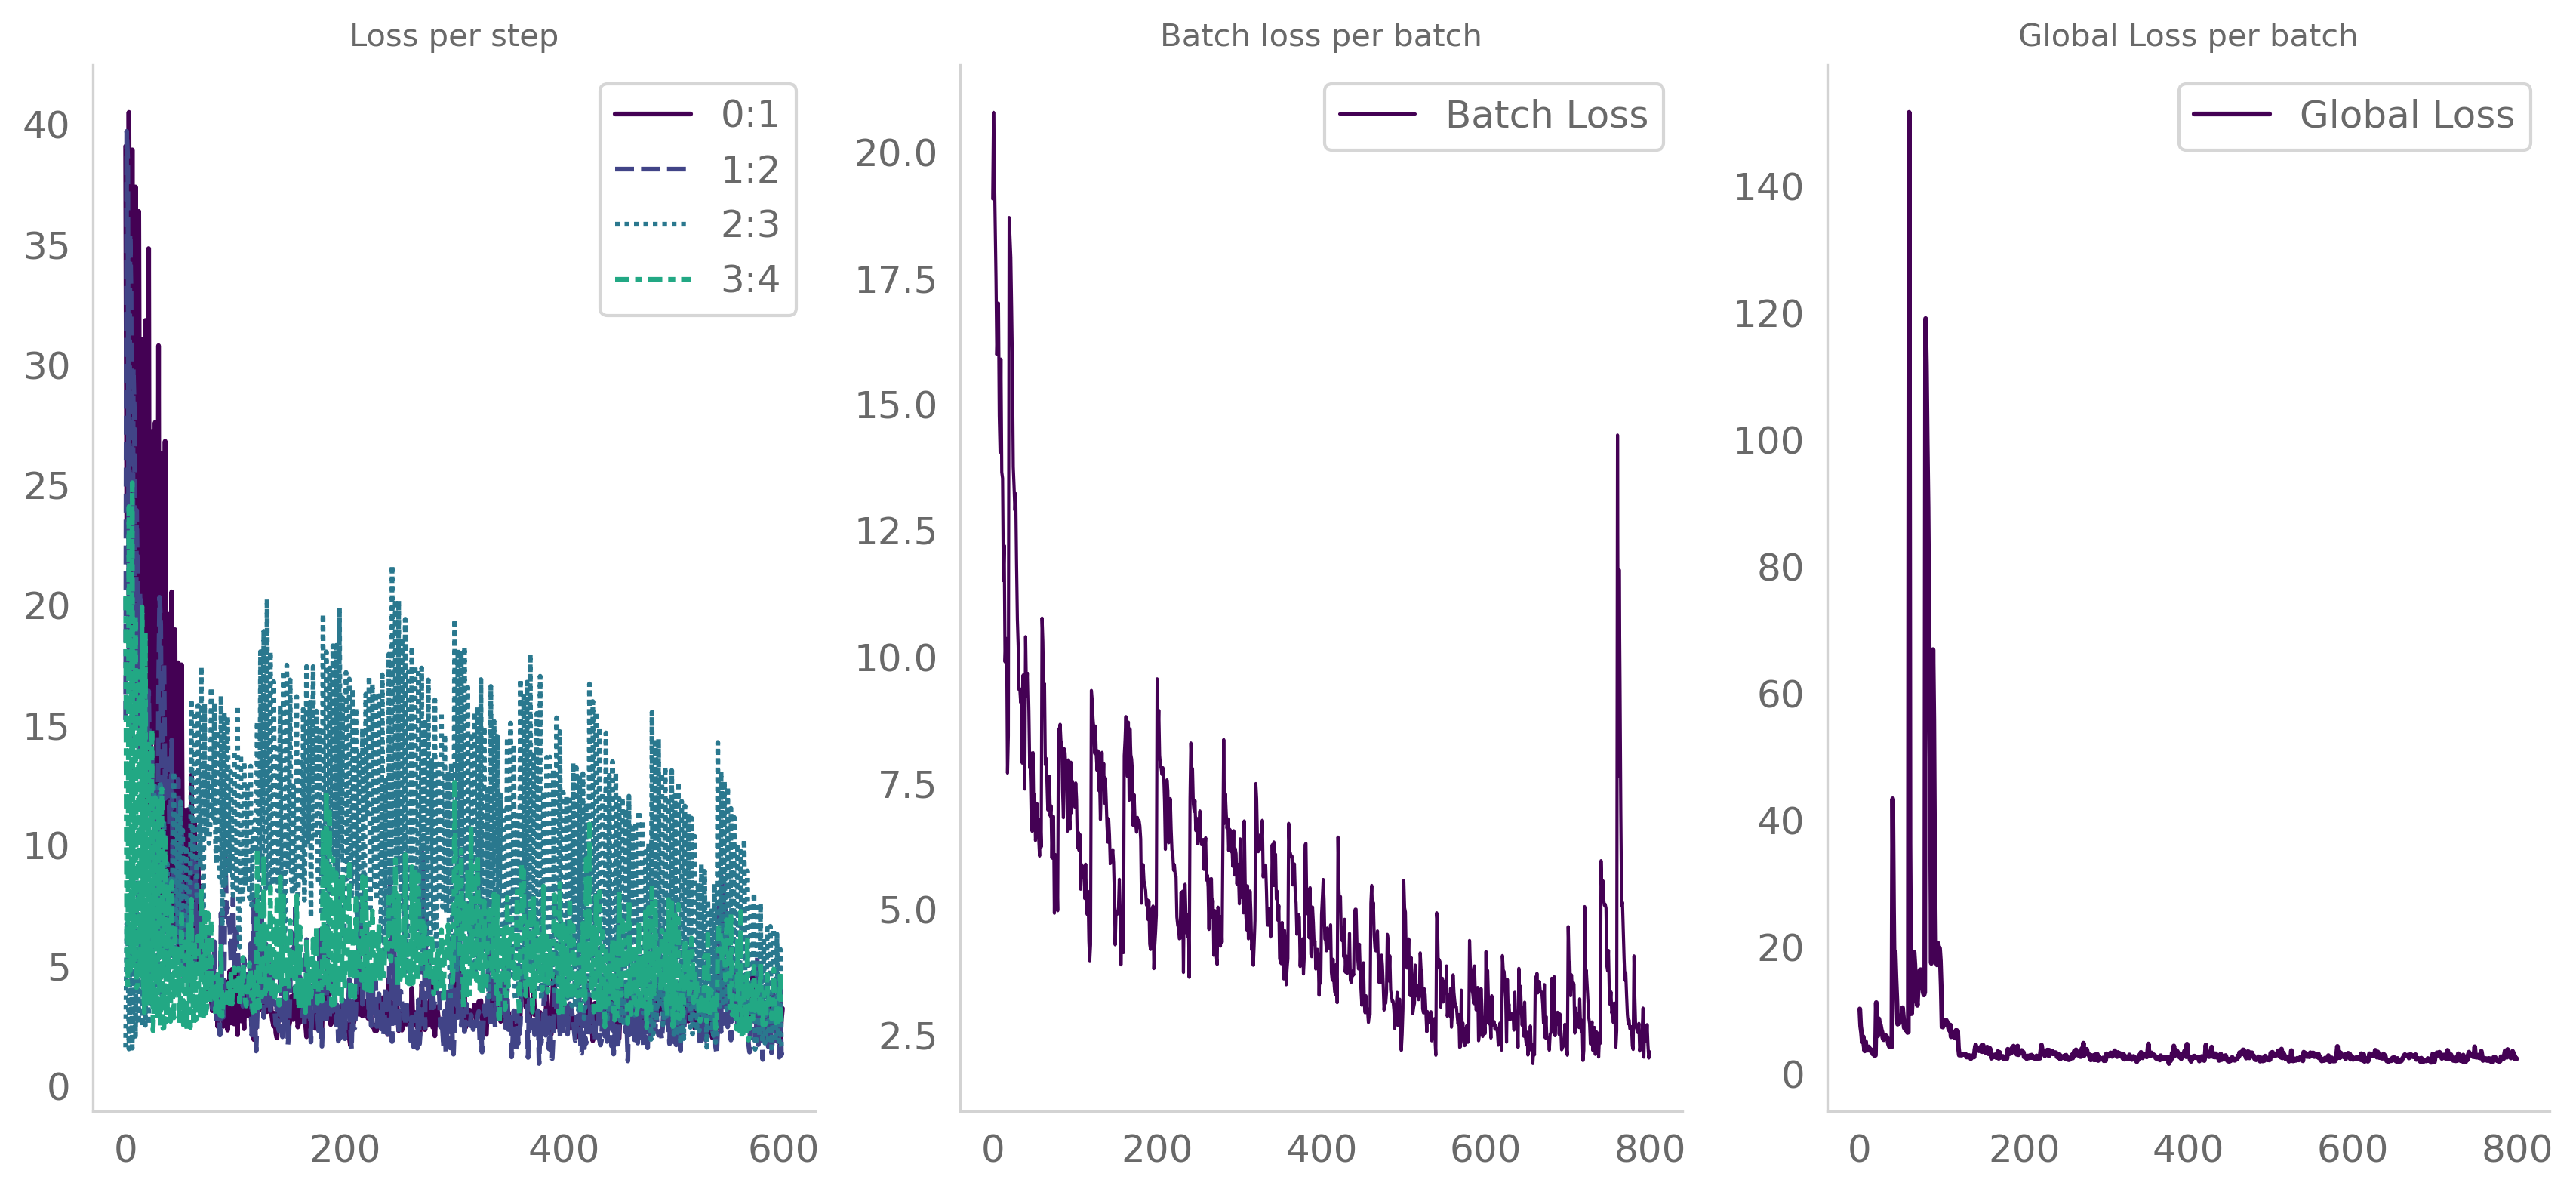

In [32]:
plot_losses(
    local_losses, 
    batch_losses, 
    globe_losses, 
    save=True, 
    path='.', 
    file='losses.png'
)

In [33]:
generated, trajectoriespts = generate_plot_data(
    model, 
    df, 
    n_points=100, 
    n_trajectories=100, 
    n_bins=100, 
    use_cuda=use_cuda, 
    samples_key='samples', 
    logger=None,
    autoencoder=None, 
    recon=None
)

## Visualizing the MIOFlow Outputs and saving

In [34]:
trajectoriespts = trajectoriespts * std_vals + mean_vals
generated = generated * std_vals + mean_vals
true_data = df[[f'd{i}' for i in range(1, len(df.columns))]] * std_vals + mean_vals

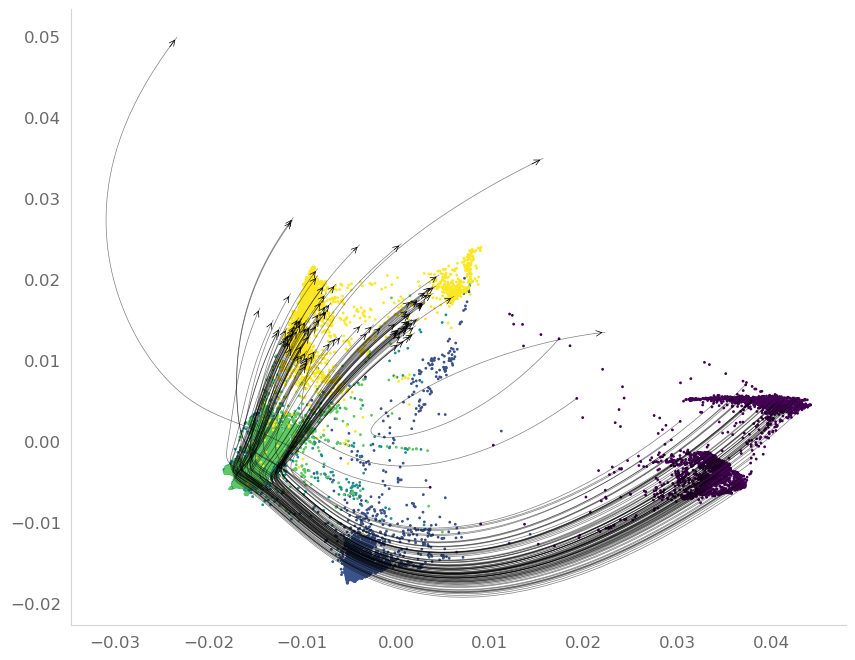

In [35]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(true_data.values[:, 0], true_data.values[:, 1], c=df['samples'].values, cmap='viridis', s=1)
for i,traj in enumerate(np.transpose(trajectoriespts, axes=(1,0,2))):
    # widths = m_traj[:,i]
    plt.plot(traj[:, 0], traj[:, 1], alpha=.5, linewidth=.5, color='Black')
    plt.annotate('', xy=(traj[-1, 0], traj[-1, 1]), xytext=(traj[-2, 0], traj[-2, 1]),
                 arrowprops=dict(arrowstyle='->', color='Black', lw=.5, mutation_scale=10))